In [ ]:
import json
import re
import os
import pandas as pd
from glob import glob
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from wordcloud import WordCloud
from collections import Counter
from collections import defaultdict
import numpy as np
import nltk
from nltk.corpus import stopwords
from pathlib import Path


ModuleNotFoundError: No module named 'wordcloud'

In [ ]:
data_folder = "/home/natsalaz/Documents/datasets/XmoPipe/xmo_data/xmopipe"
json_files = glob(f"{data_folder}/*/description_videos_*.json")
print(len(json_files), "JSON files found.")

6319 JSON files found.


In [ ]:
import re
from pathlib import Path
import json
import pandas as pd


def extract_block_items_loose(block_text):
    """Extracts everything after <ID> up to the end of the block or the next <ID>."""
    if not block_text:
        return []
    # Split on <ID> and grab text up to the next <ID> or end of block
    items = re.split(r"<\d+>", block_text)[
        1:
    ]  # first split is before the first <ID>
    return [
        m.strip().split("<")[0] for m in items
    ]  # cut at first < to avoid unclosed tags


rows = []

for json_path in json_files:
    video_id = Path(json_path).stem.replace("description_videos_", "")

    with open(json_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    for scene_key, content in data.items():
        scene_match = re.search(r"(\d+)$", scene_key)  # last digit of path
        if not scene_match:
            continue
        scene_id = scene_match.group(1)

        # Extract BodyDesc, Style and Action blocks
        body_items = extract_block_items_loose(
            re.search(r"<BodyDesc>(.*?)</BodyDesc>", content, re.DOTALL).group(1)
            if re.search(r"<BodyDesc>(.*?)</BodyDesc>", content, re.DOTALL)
            else None
        )
        style_items = extract_block_items_loose(
            re.search(r"<Style>(.*?)</Style>", content, re.DOTALL).group(1)
            if re.search(r"<Style>(.*?)</Style>", content, re.DOTALL)
            else None
        )
        action_items = extract_block_items_loose(
            re.search(r"<Action>(.*?)</Action>", content, re.DOTALL).group(1)
            if re.search(r"<Action>(.*?)</Action>", content, re.DOTALL)
            else None
        )

        # Create rows by position
        max_len = max(len(body_items), len(style_items), len(action_items))
        for i in range(max_len):
            rows.append(
                {
                    "video_id": video_id,
                    "scene_id": scene_id,
                    "person_id": str(i),
                    "body_desc": body_items[i] if i < len(body_items) else None,
                    "style": style_items[i] if i < len(style_items) else None,
                    "action": action_items[i] if i < len(action_items) else None,
                }
            )

df = pd.DataFrame(rows)
print(df.head(10))
print(f"Total sequences: {len(df)}")

In [ ]:
scene_movements = []
bodydesc_texts = []
scenedesc_texts = []

for json_path in json_files:
    match_vid = re.search(r"video_(\d+)", json_path)
    if not match_vid:
        continue
    video_id = match_vid.group(1)

    with open(json_path, "r", encoding="utf-8") as f:
        data = json.load(f)

    for scene_key, content in data.items():
        scene_match = re.search(r"(\d+)$", scene_key)
        if not scene_match:
            continue
        scene_id = scene_match.group(1)

        body_block = re.search(r"<BodyDesc>(.*?)</BodyDesc>", content, re.DOTALL)
        scene_desc = re.search(r"<SceneDesc>(.*?)</SceneDesc>", content, re.DOTALL)

        # robustly count movements
        body_count = 0
        if body_block:
            body_count = len(
                re.findall(r"<[^>]+>.*?</[^>]+>", body_block.group(1), re.DOTALL)
            )

        scene_movements.append(
            {"video_id": video_id, "scene_id": scene_id, "movement_count": body_count}
        )

        if body_block:
            bodydesc_texts.append(body_block.group(1).strip())
        if scene_desc:
            scenedesc_texts.append(scene_desc.group(1).strip())

df_movements = pd.DataFrame(scene_movements)
print(df_movements.head(10))

In [ ]:
nltk.download("stopwords")

stop_words = set(stopwords.words("english"))

def extract_words(text):
    if not text:  # skip None or empty string
        return []
    return [
        w
        for w in re.findall(r"\b\w+\b", text.lower())
        if w not in stop_words and len(w) > 1
    ]


# Collect style words safely
style_words = []
for style in df["style"]:
    style_words.extend(extract_words(style))

from collections import Counter

if style_words:
    style_counts = Counter(style_words).most_common(20)
    style_labels, style_vals = zip(*style_counts)

    fig, ax = plt.subplots(1, 1, figsize=(18, 6))
    plt.style.use("ggplot")

    def plot_pretty_bar(ax, labels, values, title, cmap_name="viridis"):
        import matplotlib.colors as mcolors

        cmap = plt.colormaps[cmap_name]
        norm = mcolors.Normalize(vmin=min(values), vmax=max(values))
        colors = [cmap(norm(val)) for val in values]
        x = range(len(labels))
        bars = ax.bar(x, values, color=colors, edgecolor="black")
        ax.set_title(title, fontsize=14, weight="bold")
        ax.set_xticks(x)
        ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=10)
        ax.tick_params(axis="y", labelsize=10)
        for bar in bars:
            height = bar.get_height()
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                height + 0.5,
                str(height),
                ha="center",
                va="bottom",
                fontsize=10,
            )
        ax.set_ylim(0, max(values) * 1.2)

    plot_pretty_bar(
        ax, style_labels, style_vals, "Top 20 style words", cmap_name="plasma"
    )
    plt.tight_layout()
    plt.show()
else:
    print("No style words found in the DataFrame.")

In [ ]:
def extract_inner_bodydesc_texts(raw_list):
    """
    Extracts the inner texts of each BodyDesc,
    even if tags are of the form <0>...</0>, <1>...</1>, etc.
    """
    texts = []
    for raw in raw_list:
        if raw:
            # catch everything between <id>...</id>
            texts.extend(
                [m.strip() for m in re.findall(r"<\d+>(.*?)</\d+>", raw, re.DOTALL)]
            )
    return texts


if "df" in locals() and "bodydesc_texts" in locals() and "scenedesc_texts" in locals():
    def show_wc(word_list, title, cmap):
        wc = WordCloud(width=800, height=400, background_color="white", colormap=cmap)
        wc.generate_from_frequencies(Counter(word_list))
        plt.figure(figsize=(14, 6))
        plt.imshow(wc, interpolation="bilinear")
        plt.axis("off")
        plt.title(title)
        plt.show()

    style_words = [w for s in df["style"] for w in extract_words(s)] if "style" in df.columns else []
    if style_words:
        style_words = [w for s in df["style"] for w in extract_words(s)]
    body_words = [
        w
        for t in extract_inner_bodydesc_texts(bodydesc_texts)
        for w in extract_words(t)
    ]
    scene_words = [w for t in scenedesc_texts for w in extract_words(t)]

    action_words = (
        [w for a in df["action"] for w in extract_words(a)]
        if "action" in df.columns
        else []
    )
    if action_words:
        action_words = [w for a in df["action"] for w in extract_words(a)]
    show_wc(style_words, "Styles", "tab10")
    show_wc(body_words, "Body Description", "tab20")
    show_wc(action_words, "Action", "Set3")
    show_wc(scene_words, "Scene Description", "tab20c")
else:
    print("Missing dataframe or description lists.")

--- Persons per scene ---
Total person sequences: 172182
Mean: 1.87
Median: 1.00
Q1: 1.00
Q3: 2.00

--- Scenes per video ---
Total scenes: 92182
Mean: 14.61
Median: 5.00
Q1: 2.00
Q3: 15.00


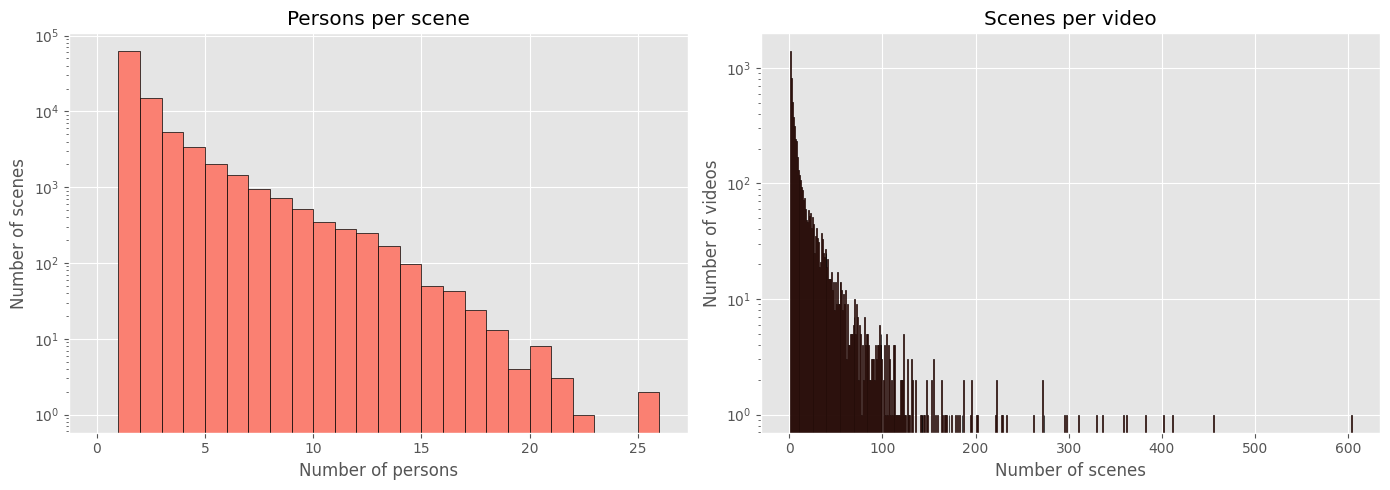

In [ ]:
if "df" in locals():

    persons_per_scene = df.groupby(["video_id", "scene_id"])["person_id"].nunique()
    scenes_per_video = df.groupby("video_id")["scene_id"].nunique()

    print("--- Persons per scene ---")
    print(f"Total person sequences: {persons_per_scene.sum()}")
    print(f"Mean: {persons_per_scene.mean():.2f}")
    print(f"Median: {persons_per_scene.median():.2f}")
    print(f"Q1: {persons_per_scene.quantile(0.25):.2f}")
    print(f"Q3: {persons_per_scene.quantile(0.75):.2f}")

    print("\n--- Scenes per video ---")
    print(f"Total scenes: {scenes_per_video.sum()}")
    print(f"Mean: {scenes_per_video.mean():.2f}")
    print(f"Median: {scenes_per_video.median():.2f}")
    print(f"Q1: {scenes_per_video.quantile(0.25):.2f}")
    print(f"Q3: {scenes_per_video.quantile(0.75):.2f}")

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].hist(
        persons_per_scene,
        bins=range(0, persons_per_scene.max() + 2),
        facecolor="salmon",
        edgecolor="black",
    )
    axes[0].set_title("Persons per scene")
    axes[0].set_xlabel("Number of persons")
    axes[0].set_ylabel("Number of scenes")
    axes[0].set_yscale("log")

    axes[1].hist(
        scenes_per_video,
        bins=range(0, scenes_per_video.max() + 2),
        edgecolor="black",
    )
    axes[1].set_title("Scenes per video")
    axes[1].set_xlabel("Number of scenes")
    axes[1].set_ylabel("Number of videos")
    axes[1].set_yscale("log")

    plt.tight_layout()
    plt.show()
else:
    print("DataFrame `df` is not defined.")

In [ ]:
print(persons_per_scene)
print(persons_per_scene.sum())
print((persons_per_scene>=2).sum())

video_id     scene_id
video_10000  1           1
             2           1
video_10001  1           1
             10          1
             11          1
                        ..
video_9999   5           1
             6           1
             7           1
             8           1
             9           1
Name: person_id, Length: 92182, dtype: int64
172182
30563


In [ ]:
import os
import json
import pandas as pd

rows = []

# Walk through current directory
for root, dirs, files in os.walk(
    "/home/natsalaz/Documents/datasets/XmoPipe/xmo_data/xmopipe"
):
    for f in files:
        if f.endswith(".json"):
            path = os.path.join(root, f)
            try:
                with open(path, "r") as fp:
                    data = json.load(fp)
                # Count elements: for dict = len(keys), for list = len(list), else 1
                if isinstance(data, dict):
                    count = len(data)
                elif isinstance(data, list):
                    count = len(data)
                else:
                    count = 1
            except Exception as e:
                count = None
            rows.append({"file": path, "num_elements": count})
print(rows)
df = pd.DataFrame(rows)
print(df)

[{'file': '/home/natsalaz/Documents/datasets/XmoPipe/xmo_data/xmopipe/video_20084/description_videos_video_20084.json', 'num_elements': 7}, {'file': '/home/natsalaz/Documents/datasets/XmoPipe/xmo_data/xmopipe/video_11688/description_videos_video_11688.json', 'num_elements': 2}, {'file': '/home/natsalaz/Documents/datasets/XmoPipe/xmo_data/xmopipe/video_8778/description_videos_video_8778.json', 'num_elements': 1}, {'file': '/home/natsalaz/Documents/datasets/XmoPipe/xmo_data/xmopipe/video_12705/description_videos_video_12705.json', 'num_elements': 12}, {'file': '/home/natsalaz/Documents/datasets/XmoPipe/xmo_data/xmopipe/video_19605/description_videos_video_19605.json', 'num_elements': 1}, {'file': '/home/natsalaz/Documents/datasets/XmoPipe/xmo_data/xmopipe/video_16873/description_videos_video_16873.json', 'num_elements': 1}, {'file': '/home/natsalaz/Documents/datasets/XmoPipe/xmo_data/xmopipe/video_14642/description_videos_video_14642.json', 'num_elements': 12}, {'file': '/home/natsalaz/D

In [ ]:
print(df["file"].count())
print(df["num_elements"].sum())

6319
92864


In [ ]:
second_max_idx = scenes_per_video.nlargest(2).index[1]
print(f"2nd max index: {second_max_idx}")
print(f"Value        : {scenes_per_video.loc[second_max_idx]}")

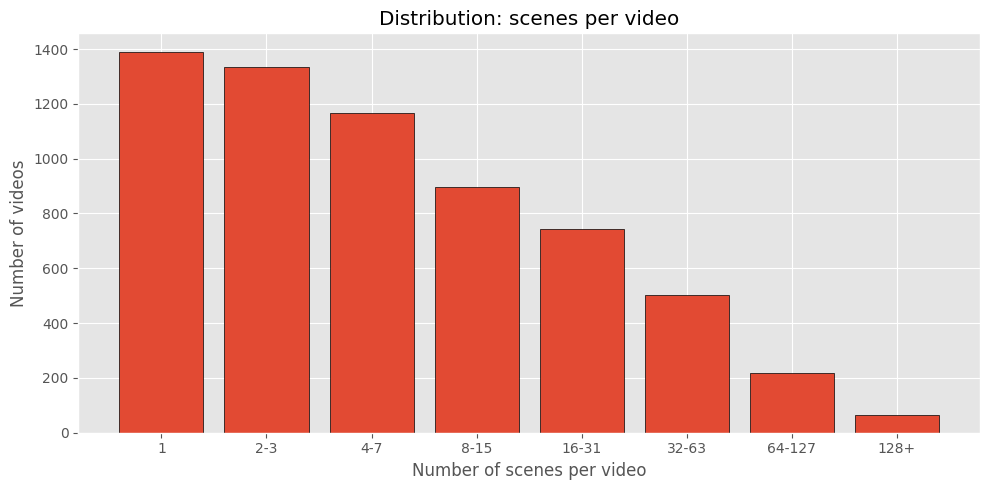

In [ ]:
custom_bins = [0, 1, 3, 7, 15, 31, 63, 127, np.inf]
custom_labels = ["1", "2-3", "4-7", "8-15", "16-31", "32-63", "64-127", "128+"]

scenes_per_video_binned = pd.cut(
    scenes_per_video, bins=custom_bins, labels=custom_labels, right=True
)

scene_bin_counts = scenes_per_video_binned.value_counts(sort=False)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(scene_bin_counts.index.astype(str), scene_bin_counts.values, edgecolor="black")
ax.set_title("Distribution: scenes per video")
ax.set_xlabel("Number of scenes per video")
ax.set_ylabel("Number of videos")
plt.tight_layout()
plt.show()

In [ ]:
from glob import glob
import numpy as np
import os

poses_files = glob(f"{data_folder}/*/*.npz")
total_frames = 0
total_face_frames = 0
bad_files = []
person_count_per_file = {}

for path in poses_files:
    try:
        data = np.load(path, allow_pickle=True)
        person_keys = [key for key in data.files if key.startswith("body_")]
        num_persons = 0
        frames_in_file = 0
        face_frames_in_file = 0
        for key in person_keys:
            body = data[key].item()
            if "poses" in body and hasattr(body["poses"], "shape"):
                n = body["poses"].shape[0]
                frames_in_file += n
                total_frames += n
                num_persons += 1
                face_n = np.sum(np.mean(np.abs(np.array(body["expressions"])), axis=1) > 1e-6)
                face_frames_in_file += face_n
                total_face_frames += face_n
        person_count_per_file[os.path.basename(path)] = {
            "num_persons": num_persons,
            "total_frames": frames_in_file,
            "face_frames": face_frames_in_file,
        }

    except Exception as e:
        bad_files.append((os.path.basename(path), str(e)))

# Summary
print(f"\nFiles processed: {len(person_count_per_file)}")
print(f"Total 3D pose frames: {total_frames:,}")

# Examples
print("\nPerson count + frames (examples):")
for fname, stats in list(person_count_per_file.items())[:10]:
    print(f"{fname}: {stats['num_persons']} persons, {stats['total_frames']} frames, {stats['face_frames']} frames with face")

if bad_files:
    print(f"\nInvalid files: {len(bad_files)}")
    for name, err in bad_files[:5]:
        print(f" - {name}: {err}")

In [ ]:
total_persons = persons_per_scene.sum()
total_scenes = persons_per_scene.index.nunique()
total_videos = scenes_per_video.index.nunique()

print(
    f"{total_persons:,} sequences and person annotations across {total_scenes:,} scenes, taken from {total_videos:,} YouTube CC videos"
    f", covering {total_frames:,} 3D poses, covering {total_face_frames:,} 3D expressions ({round(total_face_frames/total_frames*100,2)}% of all frames),"
    f"each annotated with structured descriptions of body movement, "
    f"emotion, style, and scene context."
)

172,182 sequences and person annotations across 92,182 scenes, taken from 6,309 YouTube CC videos, covering 33,768,084 3D poses, covering 16,736,574 3D expressions (49.56% of all frames),each annotated with structured descriptions of body movement, emotion, style, and scene context.


In [ ]:
print(
    round(total_frames / 30, 2),
    "s",
    round(total_frames / (60 * 30), 2),
    "min",
    round(total_frames / (3600 * 30), 2),
    "h",
)

1125602.8 s 18760.05 min 312.67 h


In [ ]:
print(df)
df_ids = df_movements.groupby(["video_id"])

                                                   file  num_elements
0     /home/natsalaz/Documents/datasets/XmoPipe/xmo_...             7
1     /home/natsalaz/Documents/datasets/XmoPipe/xmo_...             2
2     /home/natsalaz/Documents/datasets/XmoPipe/xmo_...             1
3     /home/natsalaz/Documents/datasets/XmoPipe/xmo_...            12
4     /home/natsalaz/Documents/datasets/XmoPipe/xmo_...             1
...                                                 ...           ...
6314  /home/natsalaz/Documents/datasets/XmoPipe/xmo_...             1
6315  /home/natsalaz/Documents/datasets/XmoPipe/xmo_...             2
6316  /home/natsalaz/Documents/datasets/XmoPipe/xmo_...            10
6317  /home/natsalaz/Documents/datasets/XmoPipe/xmo_...             2
6318  /home/natsalaz/Documents/datasets/XmoPipe/xmo_...            16

[6319 rows x 2 columns]


In [ ]:
total_frames = 0
total_face_frames = 0
bad_files = []
person_count_per_file = {}

for path in poses_files:
    try:
        data = np.load(path, allow_pickle=True)
        person_keys = [key for key in data.files if key.startswith("body_")]

        num_persons = 0
        max_frames_in_file = 0
        max_face_frames_in_file = 0

        for key in person_keys:
            body = data[key].item()
            if "poses" in body and hasattr(body["poses"], "shape"):
                n = body["poses"].shape[0]
                max_frames_in_file = max(max_frames_in_file, n)

                face_n = np.sum(
                    np.mean(np.abs(np.array(body["expressions"])), axis=1) > 1e-6
                )
                max_face_frames_in_file = max(max_face_frames_in_file, face_n)

                num_persons += 1

        total_frames += max_frames_in_file
        total_face_frames += max_face_frames_in_file

        person_count_per_file[os.path.basename(path)] = {
            "num_persons": num_persons,
            "scene_frames": max_frames_in_file,
            "face_frames": max_face_frames_in_file,
        }

    except Exception as e:
        bad_files.append((os.path.basename(path), str(e)))

In [ ]:
print(f"\nFiles processed: {len(person_count_per_file)}")
print(f"Total scene frames (max per file): {total_frames:,}")

print("\nScenes (examples):")
for fname, stats in list(person_count_per_file.items())[:10]:
    print(
        f"{fname}: {stats['num_persons']} persons, "
        f"{stats['scene_frames']} scene frames, "
        f"{stats['face_frames']} face frames"
    )

In [ ]:
print(total_frames)
print(total_frames/30)
print(total_frames/30/60)
print(total_frames/30/3600)

19223932
640797.7333333333
10679.96222222222
177.99937037037034


In [ ]:
print(total_face_frames)

12455794
